In [3]:
# ============================================================
# PHASE 4 — CELL 1
# INITIALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Phase 4 initialized successfully.")

Phase 4 initialized successfully.


In [4]:
# ============================================================
# PHASE 4 — CELL 2
# LOAD PHASE 3 ARTIFACTS
# ============================================================

base_path = "/content/drive/MyDrive/"

final_opportunities = pd.read_csv(
    base_path + "final_customer_sku_reorder_opportunities.csv"
)

customer_opportunities = pd.read_csv(
    base_path + "customer_reorder_opportunities.csv"
)

product_opportunities = pd.read_csv(
    base_path + "product_reorder_opportunities.csv"
)

final_summary = pd.read_csv(
    base_path + "final_model_summary.csv"
)

print("Phase 3 artifacts loaded successfully.\n")

print("Customer-SKU opportunities:",
      final_opportunities.shape)

print("Customer summary:",
      customer_opportunities.shape)

print("Product summary:",
      product_opportunities.shape)

print("Model summary:",
      final_summary.shape)

Phase 3 artifacts loaded successfully.

Customer-SKU opportunities: (2978, 14)
Customer summary: (105, 5)
Product summary: (504, 5)
Model summary: (15, 2)


In [5]:
# ============================================================
# PHASE 4 — CELL 3
# VERIFY PHASE 3 ARTIFACTS
# ============================================================

print("FINAL CUSTOMER-SKU OPPORTUNITIES")
print("--------------------------------")
print("Rows:", len(final_opportunities))

print("\nRequired columns:")
required_columns = [
    "Member",
    "SKU",
    "Description",
    "reorder_probability"
]

for col in required_columns:
    print(
        f"{col}:",
        "Available" if col in final_opportunities.columns
        else "MISSING"
    )

print("\nProbability range:")
print(
    "Minimum:",
    final_opportunities["reorder_probability"].min()
)

print(
    "Maximum:",
    final_opportunities["reorder_probability"].max()
)

print("\nTop 5 opportunities:")
display(final_opportunities.head())

FINAL CUSTOMER-SKU OPPORTUNITIES
--------------------------------
Rows: 2978

Required columns:
Member: Available
SKU: Available
Description: Available
reorder_probability: Available

Probability range:
Minimum: 0.5400353284391913
Maximum: 0.9896125034345996

Top 5 opportunities:


,Member,SKU,Description,purchase_count,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,customer_lifetime_days,sku_total_purchases,sku_unique_customers,reorder_probability,predicted_reorder
0,M39021,7580802,Sunflower Oils,31,30,True,0.31,37,8.73,535.90,163,21,0.99,1
1,M27458,15668467,Beans,23,22,True,4.64,64,6.25,529.60,841,87,0.99,1
2,M14746,15668451,Brinjals,18,17,True,3.68,55,9.53,539.49,570,75,0.99,1
3,M91098,15668451,Brinjals,19,18,True,7.19,47,7.91,527.16,570,75,0.99,1
4,M64055,15668416,Banana,32,31,True,4.37,46,10.02,546.00,825,72,0.98,1


In [6]:
# ============================================================
# PHASE 4 — CELL 4
# BUILD REORDER PRIORITY SYSTEM
# ============================================================

phase4_opportunities = final_opportunities.copy()

# Primary priority score
phase4_opportunities["priority_score"] = (
    phase4_opportunities["reorder_probability"] * 100
)

# Business priority categories
phase4_opportunities["priority"] = pd.cut(
    phase4_opportunities["reorder_probability"],
    bins=[0, 0.60, 0.80, 1.00],
    labels=["Medium", "High", "Very High"],
    include_lowest=True
)

# Highest probability first
phase4_opportunities = (
    phase4_opportunities
    .sort_values(
        "reorder_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print("PHASE 4 — REORDER PRIORITY SYSTEM")
print("-----------------------------------")

print("\nPriority distribution:")
print(
    phase4_opportunities["priority"]
    .value_counts()
    .sort_index()
)

print("\nTop 20 highest-priority opportunities:")

display(
    phase4_opportunities[
        [
            "Member",
            "SKU",
            "Description",
            "purchase_count",
            "reorder_count",
            "recency_days",
            "reorder_probability",
            "priority"
        ]
    ].head(20)
)

PHASE 4 — REORDER PRIORITY SYSTEM
-----------------------------------

Priority distribution:
priority
Medium        580
High         1473
Very High     925
Name: count, dtype: int64

Top 20 highest-priority opportunities:


,Member,SKU,Description,purchase_count,reorder_count,recency_days,reorder_probability,priority
0,M39021,7580802,Sunflower Oils,31,30,0.31,0.99,Very High
1,M27458,15668467,Beans,23,22,4.64,0.99,Very High
2,M14746,15668451,Brinjals,18,17,3.68,0.99,Very High
3,M91098,15668451,Brinjals,19,18,7.19,0.99,Very High
4,M64055,15668416,Banana,32,31,4.37,0.98,Very High
5,M77779,15668462,Gourd & Cucumber,25,24,1.49,0.98,Very High
6,M27458,15668465,Root Vegetables,18,17,4.64,0.98,Very High
7,M09736,15669856,Sugar,13,12,7.48,0.98,Very High
8,M39021,15668375,Root Vegetables,11,10,0.31,0.98,Very High
9,M47229,15668378,Other Vegetables,13,12,2.35,0.98,Very High


In [7]:
# ============================================================
# PHASE 4 — CELL 5
# PRIORITY DISTRIBUTION
# ============================================================

priority_summary = (
    phase4_opportunities
    .groupby("priority", observed=False)
    .agg(
        customer_sku_pairs=("Member", "count"),
        avg_probability=("reorder_probability", "mean"),
        max_probability=("reorder_probability", "max")
    )
    .reset_index()
)

priority_summary["percentage"] = (
    priority_summary["customer_sku_pairs"]
    / len(phase4_opportunities)
    * 100
)

print(priority_summary)

    priority  customer_sku_pairs  avg_probability  max_probability  percentage
0     Medium                 580             0.57             0.60       19.48
1       High                1473             0.70             0.80       49.46
2  Very High                 925             0.88             0.99       31.06


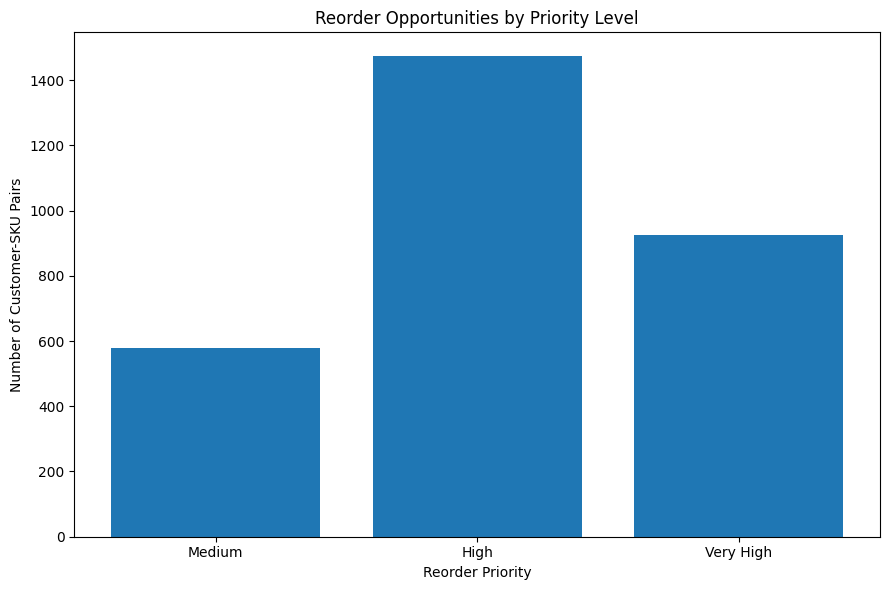

In [8]:
# ============================================================
# PHASE 4 — CELL 6
# PRIORITY DISTRIBUTION CHART
# ============================================================

plot_data = priority_summary.copy()

plt.figure(figsize=(9, 6))

plt.bar(
    plot_data["priority"].astype(str),
    plot_data["customer_sku_pairs"]
)

plt.xlabel("Reorder Priority")
plt.ylabel("Number of Customer-SKU Pairs")
plt.title("Reorder Opportunities by Priority Level")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# PHASE 4 — CELL 7
# CUSTOMER-LEVEL PRIORITIZATION
# ============================================================

customer_priority = (
    phase4_opportunities
    .groupby("Member")
    .agg(
        predicted_reorders=("SKU", "count"),
        avg_reorder_probability=(
            "reorder_probability",
            "mean"
        ),
        max_reorder_probability=(
            "reorder_probability",
            "max"
        )
    )
    .reset_index()
)

customer_priority["priority_score"] = (
    customer_priority["avg_reorder_probability"] * 100
)

customer_priority = customer_priority.sort_values(
    [
        "predicted_reorders",
        "avg_reorder_probability"
    ],
    ascending=False
).reset_index(drop=True)

print("Top customers by predicted reorder opportunities:")

display(customer_priority.head(20))

Top customers by predicted reorder opportunities:


,Member,predicted_reorders,avg_reorder_probability,max_reorder_probability,priority_score
0,M38622,65,0.74,0.96,73.88
1,M41747,51,0.74,0.96,74.14
2,M09736,49,0.80,0.98,79.77
3,M33064,49,0.75,0.95,74.97
4,M36432,47,0.72,0.93,72.15
5,M41781,46,0.69,0.96,69.48
6,M14746,45,0.73,0.99,73.09
7,M35649,44,0.71,0.90,71.01
8,M78365,42,0.73,0.96,72.54
9,M84827,41,0.73,0.98,72.99


In [10]:
# ============================================================
# PHASE 4 — CELL 8
# PRODUCT-LEVEL PRIORITIZATION
# ============================================================

product_priority = (
    phase4_opportunities
    .groupby(["SKU", "Description"])
    .agg(
        predicted_reorders=("SKU", "count"),
        avg_reorder_probability=(
            "reorder_probability",
            "mean"
        ),
        max_reorder_probability=(
            "reorder_probability",
            "max"
        )
    )
    .reset_index()
)

product_priority["priority_score"] = (
    product_priority["avg_reorder_probability"] * 100
)

product_priority = product_priority.sort_values(
    [
        "predicted_reorders",
        "avg_reorder_probability"
    ],
    ascending=False
).reset_index(drop=True)

print("Top products by predicted reorder opportunities:")

display(product_priority.head(20))

Top products by predicted reorder opportunities:


,SKU,Description,predicted_reorders,avg_reorder_probability,max_reorder_probability,priority_score
0,15668381,Other Vegetables,84,0.80,0.96,79.98
1,15668688,Root Vegetables,78,0.77,0.96,77.17
2,15668379,Other Vegetables,72,0.76,0.95,76.05
3,15668460,Gourd & Cucumber,63,0.82,0.95,81.55
4,15668468,Beans,63,0.76,0.96,76.40
5,15668478,Banana,60,0.80,0.95,80.31
6,15668467,Beans,60,0.75,0.99,75.50
7,15668378,Other Vegetables,57,0.79,0.98,79.21
8,15668465,Root Vegetables,56,0.78,0.98,78.12
9,15668375,Root Vegetables,52,0.77,0.98,76.85


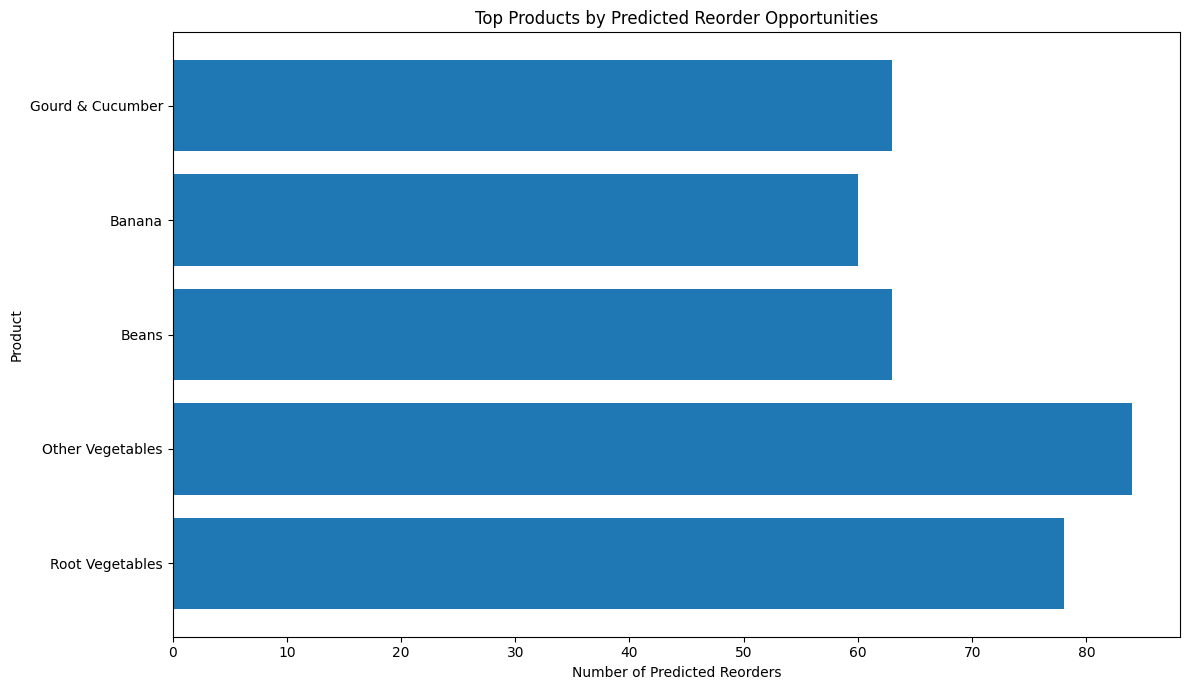

In [11]:
# ============================================================
# PHASE 4 — CELL 9
# TOP PRODUCTS
# ============================================================

top_products = product_priority.head(10).copy()

plt.figure(figsize=(12, 7))

plt.barh(
    top_products["Description"].astype(str)[::-1],
    top_products["predicted_reorders"][::-1]
)

plt.xlabel("Number of Predicted Reorders")
plt.ylabel("Product")
plt.title("Top Products by Predicted Reorder Opportunities")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# PHASE 4 — CELL 10
# HIGH-CONFIDENCE OPPORTUNITIES
# ============================================================

high_confidence = phase4_opportunities[
    phase4_opportunities["reorder_probability"] >= 0.80
].copy()

high_confidence = high_confidence.sort_values(
    "reorder_probability",
    ascending=False
)

print(
    "High-confidence opportunities "
    "(probability >= 80%):",
    len(high_confidence)
)

print(
    "Percentage of predicted opportunities:",
    len(high_confidence)
    / len(phase4_opportunities)
    * 100,
    "%"
)

display(
    high_confidence[
        [
            "Member",
            "SKU",
            "Description",
            "purchase_count",
            "reorder_count",
            "recency_days",
            "reorder_probability",
            "priority"
        ]
    ].head(30)
)

High-confidence opportunities (probability >= 80%): 925
Percentage of predicted opportunities: 31.061114842175957 %


,Member,SKU,Description,purchase_count,reorder_count,recency_days,reorder_probability,priority
0,M39021,7580802,Sunflower Oils,31,30,0.31,0.99,Very High
1,M27458,15668467,Beans,23,22,4.64,0.99,Very High
2,M14746,15668451,Brinjals,18,17,3.68,0.99,Very High
3,M91098,15668451,Brinjals,19,18,7.19,0.99,Very High
4,M64055,15668416,Banana,32,31,4.37,0.98,Very High
5,M77779,15668462,Gourd & Cucumber,25,24,1.49,0.98,Very High
6,M27458,15668465,Root Vegetables,18,17,4.64,0.98,Very High
7,M09736,15669856,Sugar,13,12,7.48,0.98,Very High
8,M39021,15668375,Root Vegetables,11,10,0.31,0.98,Very High
9,M47229,15668378,Other Vegetables,13,12,2.35,0.98,Very High


In [13]:
# ============================================================
# PHASE 4 — CELL 11
# VERY HIGH-CONFIDENCE OPPORTUNITIES
# ============================================================

very_high_confidence = phase4_opportunities[
    phase4_opportunities["reorder_probability"] >= 0.90
].copy()

print(
    "Very high-confidence opportunities "
    "(probability >= 90%):",
    len(very_high_confidence)
)

print(
    "Percentage of all predicted opportunities:",
    len(very_high_confidence)
    / len(phase4_opportunities)
    * 100,
    "%"
)

display(
    very_high_confidence[
        [
            "Member",
            "SKU",
            "Description",
            "reorder_probability"
        ]
    ].head(30)
)

Very high-confidence opportunities (probability >= 90%): 337
Percentage of all predicted opportunities: 11.316319677635997 %


,Member,SKU,Description,reorder_probability
0,M39021,7580802,Sunflower Oils,0.99
1,M27458,15668467,Beans,0.99
2,M14746,15668451,Brinjals,0.99
3,M91098,15668451,Brinjals,0.99
4,M64055,15668416,Banana,0.98
5,M77779,15668462,Gourd & Cucumber,0.98
6,M27458,15668465,Root Vegetables,0.98
7,M09736,15669856,Sugar,0.98
8,M39021,15668375,Root Vegetables,0.98
9,M47229,15668378,Other Vegetables,0.98


In [14]:
# ============================================================
# PHASE 4 — CELL 12
# FINAL RECOMMENDATION TABLE
# ============================================================

recommendations = phase4_opportunities[
    [
        "Member",
        "SKU",
        "Description",
        "reorder_probability",
        "priority",
        "purchase_count",
        "reorder_count",
        "recency_days",
        "avg_basket_size"
    ]
].copy()

recommendations = recommendations.rename(
    columns={
        "Member": "Customer",
        "SKU": "Product_ID",
        "Description": "Product",
        "reorder_probability": "Reorder_Probability",
        "purchase_count": "Purchase_Count",
        "reorder_count": "Previous_Reorders",
        "recency_days": "Recency_Days",
        "avg_basket_size": "Avg_Basket_Size"
    }
)

recommendations["Reorder_Probability"] *= 100

print("FINAL REORDER RECOMMENDATIONS")

display(
    recommendations.head(30)
)

FINAL REORDER RECOMMENDATIONS


,Customer,Product_ID,Product,Reorder_Probability,priority,Purchase_Count,Previous_Reorders,Recency_Days,Avg_Basket_Size
0,M39021,7580802,Sunflower Oils,98.96,Very High,31,30,0.31,8.73
1,M27458,15668467,Beans,98.69,Very High,23,22,4.64,6.25
2,M14746,15668451,Brinjals,98.55,Very High,18,17,3.68,9.53
3,M91098,15668451,Brinjals,98.53,Very High,19,18,7.19,7.91
4,M64055,15668416,Banana,98.50,Very High,32,31,4.37,10.02
5,M77779,15668462,Gourd & Cucumber,98.34,Very High,25,24,1.49,10.34
6,M27458,15668465,Root Vegetables,98.23,Very High,18,17,4.64,6.25
7,M09736,15669856,Sugar,98.18,Very High,13,12,7.48,10.70
8,M39021,15668375,Root Vegetables,98.12,Very High,11,10,0.31,8.73
9,M47229,15668378,Other Vegetables,98.09,Very High,13,12,2.35,11.10


In [15]:
# ============================================================
# PHASE 4 — CELL 13
# SAVE PHASE 4 OUTPUTS
# ============================================================

output_path = "/content/drive/MyDrive/"

phase4_opportunities.to_csv(
    output_path + "phase4_reorder_opportunities.csv",
    index=False
)

priority_summary.to_csv(
    output_path + "phase4_priority_summary.csv",
    index=False
)

customer_priority.to_csv(
    output_path + "phase4_customer_priority.csv",
    index=False
)

product_priority.to_csv(
    output_path + "phase4_product_priority.csv",
    index=False
)

recommendations.to_csv(
    output_path + "phase4_final_recommendations.csv",
    index=False
)

high_confidence.to_csv(
    output_path + "phase4_high_confidence_opportunities.csv",
    index=False
)

very_high_confidence.to_csv(
    output_path + "phase4_very_high_confidence_opportunities.csv",
    index=False
)

print("All Phase 4 outputs saved successfully.")

All Phase 4 outputs saved successfully.


In [16]:
# ============================================================
# PHASE 4 — CELL 14
# FINAL PHASE 4 SUMMARY — CORRECTED
# ============================================================

total_evaluation_pairs = 14096

predicted_opportunities = len(phase4_opportunities)

predicted_opportunity_rate = (
    predicted_opportunities
    / total_evaluation_pairs
    * 100
)

phase4_final_summary = pd.DataFrame({
    "Metric": [
        "Total evaluation customer-SKU pairs",
        "Predicted reorder opportunities",
        "Predicted opportunity rate (%)",
        "Medium priority opportunities",
        "High priority opportunities",
        "Very High priority opportunities",
        "High-confidence opportunities (>=80%)",
        "Very high-confidence opportunities (>=90%)",
        "Average predicted reorder probability",
        "Maximum predicted reorder probability"
    ],

    "Value": [
        total_evaluation_pairs,

        predicted_opportunities,

        predicted_opportunity_rate,

        (
            phase4_opportunities["priority"]
            .eq("Medium")
            .sum()
        ),

        (
            phase4_opportunities["priority"]
            .eq("High")
            .sum()
        ),

        (
            phase4_opportunities["priority"]
            .eq("Very High")
            .sum()
        ),

        len(high_confidence),

        len(very_high_confidence),

        phase4_opportunities[
            "reorder_probability"
        ].mean() * 100,

        phase4_opportunities[
            "reorder_probability"
        ].max() * 100
    ]
})

print("==============================================")
print("FINAL PHASE 4 SUMMARY")
print("==============================================")

print(
    phase4_final_summary.to_string(index=False)
)

phase4_final_summary.to_csv(
    output_path + "phase4_final_summary.csv",
    index=False
)

FINAL PHASE 4 SUMMARY
                                    Metric    Value
       Total evaluation customer-SKU pairs 14096.00
           Predicted reorder opportunities  2978.00
            Predicted opportunity rate (%)    21.13
             Medium priority opportunities   580.00
               High priority opportunities  1473.00
          Very High priority opportunities   925.00
     High-confidence opportunities (>=80%)   925.00
Very high-confidence opportunities (>=90%)   337.00
     Average predicted reorder probability    72.95
     Maximum predicted reorder probability    98.96


In [17]:
# ============================================
# POWER BI EXPORT — PHASE 4
# ============================================

import os

export_dir = "/content/drive/MyDrive/reorder_powerbi"

os.makedirs(export_dir, exist_ok=True)

print("Export directory:", export_dir)

Export directory: /content/drive/MyDrive/reorder_powerbi


In [18]:
print("Available DataFrames:")
for name, obj in globals().items():
    if hasattr(obj, "shape") and hasattr(obj, "columns"):
        print(f"{name}: {obj.shape}")

Available DataFrames:
final_opportunities: (2978, 14)
customer_opportunities: (105, 5)
product_opportunities: (504, 5)
final_summary: (15, 2)
phase4_opportunities: (2978, 16)
priority_summary: (3, 5)
plot_data: (3, 5)
customer_priority: (105, 5)
product_priority: (504, 6)
top_products: (10, 6)
high_confidence: (925, 16)
very_high_confidence: (337, 16)
recommendations: (2978, 9)
phase4_final_summary: (10, 2)
